Deep Learning Assignment 2

Name : Raghavendra Prasad

Roll.no : 27PGAI0052

Imports and **setup**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, models

import matplotlib.pyplot as plt
import numpy as np
import os
import zipfile

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


Load Fashion-MNIST

Fashion-MNIST contains grayscale 28 × 28 images.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.94MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 16.0MB/s]

Training samples: 60000
Testing samples: 10000


Fashion-MNIST **images**

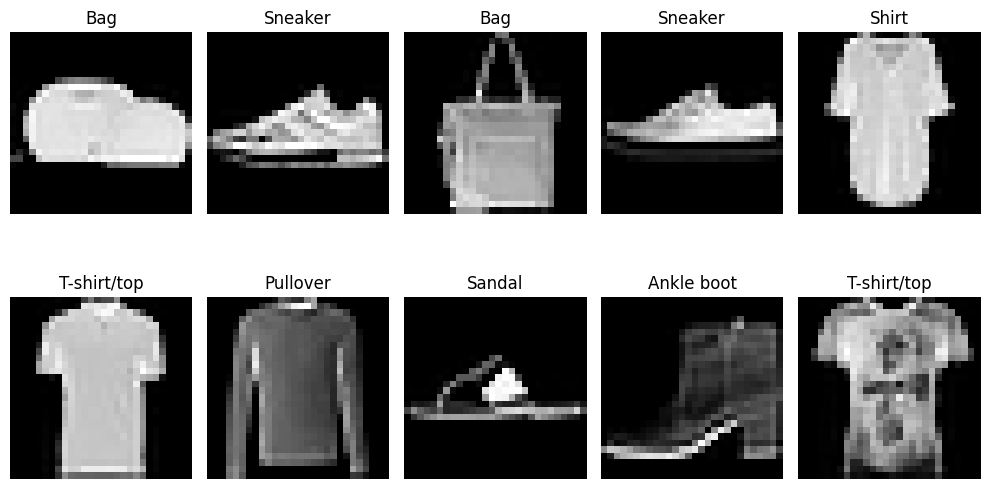

In [3]:
classes = train_dataset.classes

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
class SmallCNN(nn.Module):

    def __init__(self):
        super(SmallCNN, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64 * 7 * 7, 128),

            nn.ReLU(),

            nn.Linear(128, 10)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

model and count **parameters**

In [5]:
cnn_model = SmallCNN().to(device)

print(cnn_model)

SmallCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [6]:
trainable_params = sum(
    p.numel()
    for p in cnn_model.parameters()
    if p.requires_grad
)

print("Trainable parameters:", trainable_params)

Trainable parameters: 421642


Loss function and **optimizer**

In [7]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    cnn_model.parameters(),
    lr=0.001
)

Train **CNN**

In [8]:
num_epochs = 5

train_losses = []

for epoch in range(num_epochs):

    cnn_model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = cnn_model(images)

        loss = criterion(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch [1/5] Loss: 0.4429
Epoch [2/5] Loss: 0.2812
Epoch [3/5] Loss: 0.2368
Epoch [4/5] Loss: 0.2038
Epoch [5/5] Loss: 0.1761


Plot training **loss**

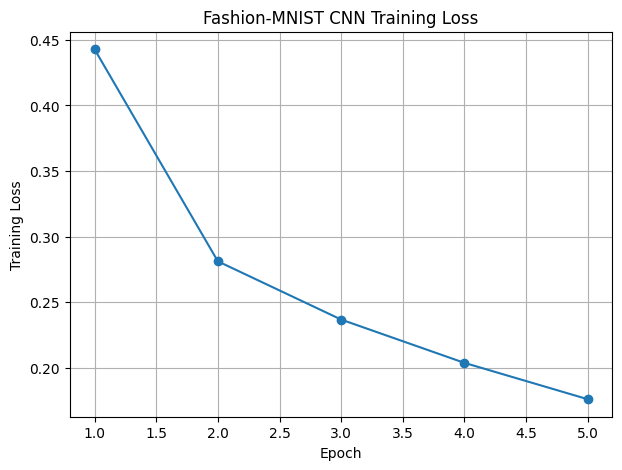

In [9]:
plt.figure(figsize=(7, 5))

plt.plot(
    range(1, num_epochs + 1),
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Fashion-MNIST CNN Training Loss")

plt.grid()
plt.show()

Evaluate test **accuracy**

In [10]:
cnn_model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = cnn_model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 91.37%


**predictions**

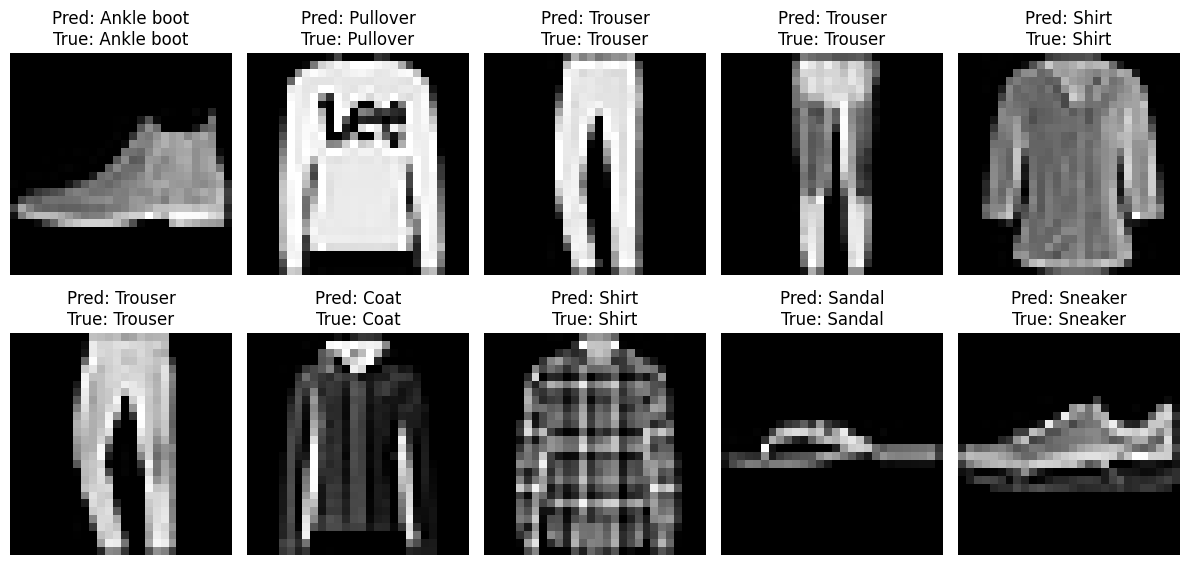

In [11]:
cnn_model.eval()

images, labels = next(iter(test_loader))

images_device = images.to(device)

with torch.no_grad():
    outputs = cnn_model(images_device)
    predictions = outputs.argmax(dim=1).cpu()

plt.figure(figsize=(12, 6))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        images[i].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Pred: {classes[predictions[i]]}\n"
        f"True: {classes[labels[i]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# Transfer Learning with ResNet18

Ants vs Bees **dataset**

In [12]:
import urllib.request

url = "https://download.pytorch.org/tutorial/hymenoptera_data.zip"

zip_path = "./hymenoptera_data.zip"

urllib.request.urlretrieve(url, zip_path)

print("Dataset downloaded.")

Dataset downloaded.


In [13]:
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("./")

print("Dataset extracted.")

Dataset extracted.


Transform **images**

In [14]:
data_transforms = {

    "train": transforms.Compose([

        transforms.RandomResizedCrop(224),

        transforms.RandomHorizontalFlip(),

        transforms.ToTensor(),

        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ]),

    "val": transforms.Compose([

        transforms.Resize(256),

        transforms.CenterCrop(224),

        transforms.ToTensor(),

        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ])
}

Load Ants vs **Bees**

In [15]:
data_dir = "./hymenoptera_data"

image_datasets = {

    x: datasets.ImageFolder(
        os.path.join(data_dir, x),
        data_transforms[x]
    )

    for x in ["train", "val"]
}

dataloaders = {

    x: DataLoader(
        image_datasets[x],
        batch_size=16,
        shuffle=(x == "train"),
        num_workers=0
    )

    for x in ["train", "val"]
}

dataset_sizes = {
    x: len(image_datasets[x])
    for x in ["train", "val"]
}

class_names = image_datasets["train"].classes

print("Classes:", class_names)
print("Training images:", dataset_sizes["train"])
print("Validation images:", dataset_sizes["val"])

Classes: ['ants', 'bees']
Training images: 244
Validation images: 153


Load pretrained **ResNet18**

In [16]:
weights = models.ResNet18_Weights.DEFAULT

resnet = models.resnet18(weights=weights)

resnet = resnet.to(device)

print(resnet)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 82.6MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Freeze the **backbone**

In [17]:
for param in resnet.parameters():
    param.requires_grad = False

In [18]:
num_features = resnet.fc.in_features

resnet.fc = nn.Linear(
    num_features,
    2
)

resnet = resnet.to(device)

print(resnet.fc)

Linear(in_features=512, out_features=2, bias=True)


Check trainable **parameters**

In [19]:
trainable_params_resnet = sum(
    p.numel()
    for p in resnet.parameters()
    if p.requires_grad
)

print(
    "Trainable parameters in ResNet18:",
    trainable_params_resnet
)

Trainable parameters in ResNet18: 1026


Loss and **optimizer**

In [20]:
criterion_resnet = nn.CrossEntropyLoss()

optimizer_resnet = optim.Adam(
    resnet.fc.parameters(),
    lr=0.001
)

In [21]:
resnet.fc.parameters()

<generator object Module.parameters at 0x7b78b413b140>

Train ResNet18 **classifier**

In [22]:
num_epochs = 5

for epoch in range(num_epochs):

    resnet.train()

    running_loss = 0.0

    for images, labels in dataloaders["train"]:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_resnet.zero_grad()

        outputs = resnet(images)

        loss = criterion_resnet(
            outputs,
            labels
        )

        loss.backward()

        optimizer_resnet.step()

        running_loss += loss.item()

    epoch_loss = (
        running_loss /
        len(dataloaders["train"])
    )

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch [1/5] Loss: 0.6024
Epoch [2/5] Loss: 0.4341
Epoch [3/5] Loss: 0.3449
Epoch [4/5] Loss: 0.3155
Epoch [5/5] Loss: 0.2858


Validation accuracy

In [23]:
resnet.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in dataloaders["val"]:

        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet(images)

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

validation_accuracy = (
    100 * correct / total
)

print(
    f"Validation Accuracy: "
    f"{validation_accuracy:.2f}%"
)

Validation Accuracy: 92.81%


**Problem 1 [10 points] - CNN/TRANSFER-LEARNING**


**Train a small CNN on Fashion-MNIST. Report test accuracy and trainable parameter count.**


Fashion-MNIST CNN Results

Test Accuracy: 91.37%

Trainable Parameters: 421,642

Number of Epochs: 5

**Use a pretrained ResNet18 on ants-vs-bees. Freeze the backbone, replace the final classifier, and train the classifier. Report validation accuracy.**

**ResNet18 Transfer Learning Results**

Dataset: Ants vs Bees

Model: Pretrained ResNet18

Backbone: Frozen

Trainable Layer: Final fully connected classifier

Validation Accuracy: 92.81%

**Answer in a markdown cell: What advantage does transfer learning provide? Comment briefly on the performance and size of your Fashion-MNIST CNN.**

**What advantage does transfer learning provide?**

Transfer learning allows a model pretrained on a large dataset to reuse features that it has already learned, instead of learning all features from the beginning. In this assignment, the pretrained ResNet18 backbone provides useful visual features, while only the final classifier is trained for the ants-vs-bees classification task. This reduces training time and the amount of data and computation required compared with training the complete network from scratch.

**Comment on the performance and size of the Fashion-MNIST CNN.**

The Fashion-MNIST CNN is relatively small compared with large deep learning architectures. It contains 421,642 trainable parameters and can be trained efficiently while achieving good classification performance. Its convolution and pooling layers learn spatial features from the images, while the fully connected layers perform the final classification. The model provides a good balance between model size, computational cost, and accuracy.

**Problem 2 [10 points] - AUTOENCODER/VAE**

**Part A — Autoencoder**

Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


Load MNIST

In [2]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 506kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.64MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.40MB/s]

Training samples: 60000
Testing samples: 10000


Display original images

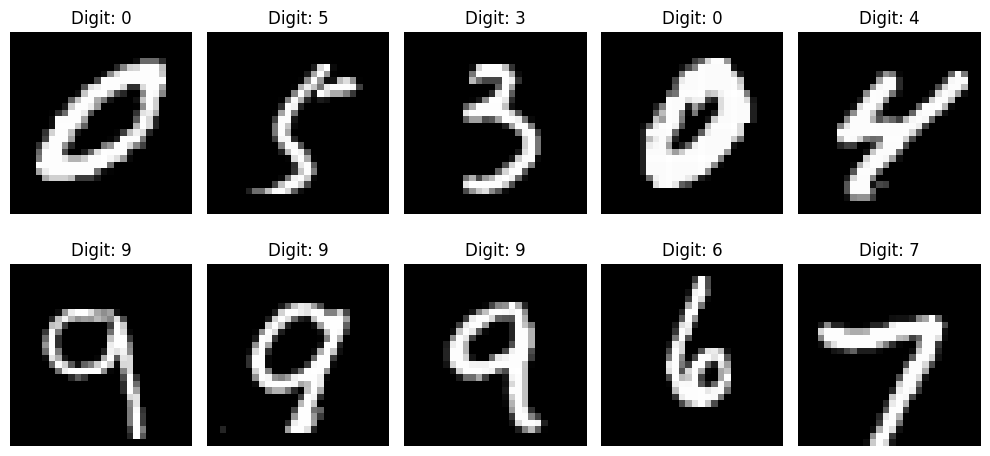

In [3]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Digit: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Autoencoder model

In [4]:
class Autoencoder(nn.Module):

    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(

            nn.Linear(28 * 28, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32)
        )

        # Decoder
        self.decoder = nn.Sequential(

            nn.Linear(32, 64),
            nn.ReLU(),

            nn.Linear(64, 128),
            nn.ReLU(),

            nn.Linear(128, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):

        # Flatten image
        x = x.view(x.size(0), -1)

        # Encode
        latent = self.encoder(x)

        # Decode
        reconstructed = self.decoder(latent)

        # Convert back to image
        reconstructed = reconstructed.view(
            x.size(0), 1, 28, 28
        )

        return reconstructed

Create model

In [5]:
autoencoder = Autoencoder().to(device)

print(autoencoder)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


Loss and optimizer

In [6]:
criterion = nn.MSELoss()

optimizer = optim.Adam(
    autoencoder.parameters(),
    lr=0.001
)

Train Autoencoder

In [7]:
num_epochs = 5

ae_losses = []

for epoch in range(num_epochs):

    autoencoder.train()

    running_loss = 0.0

    for images, _ in train_loader:

        images = images.to(device)

        # Forward pass
        reconstructed = autoencoder(images)

        # Compare original and reconstructed
        loss = criterion(
            reconstructed,
            images
        )

        # Backpropagation
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = (
        running_loss /
        len(train_loader)
    )

    ae_losses.append(epoch_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.6f}"
    )

Epoch [1/5] Loss: 0.058080
Epoch [2/5] Loss: 0.030029
Epoch [3/5] Loss: 0.023951
Epoch [4/5] Loss: 0.020980
Epoch [5/5] Loss: 0.018864


Plot Autoencoder loss

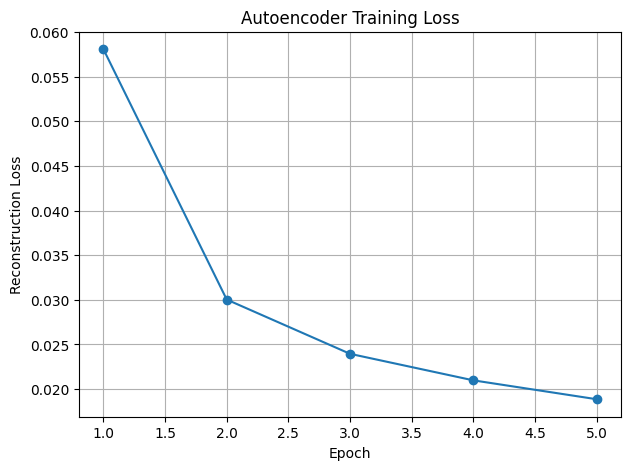

In [8]:
plt.figure(figsize=(7, 5))

plt.plot(
    range(1, num_epochs + 1),
    ae_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Autoencoder Training Loss")

plt.grid()
plt.show()

Original vs Reconstructed Images

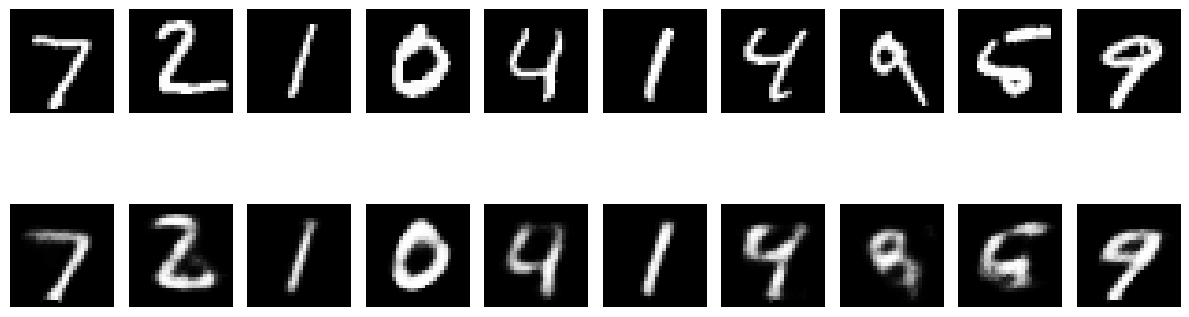

In [9]:
autoencoder.eval()

images, labels = next(iter(test_loader))

images_device = images.to(device)

with torch.no_grad():

    reconstructed = autoencoder(
        images_device
    )

reconstructed = reconstructed.cpu()

plt.figure(figsize=(12, 5))

for i in range(10):

    # Original
    plt.subplot(2, 10, i + 1)

    plt.imshow(
        images[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

    if i == 0:
        plt.ylabel("Original")

    # Reconstruction
    plt.subplot(2, 10, i + 11)

    plt.imshow(
        reconstructed[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

    if i == 0:
        plt.ylabel("Reconstructed")

plt.tight_layout()
plt.show()

Variational Autoencoder

VAE model

In [10]:
class VAE(nn.Module):

    def __init__(self, latent_dim=20):

        super(VAE, self).__init__()

        self.latent_dim = latent_dim

        # Encoder
        self.fc1 = nn.Linear(
            28 * 28,
            256
        )

        # Mean
        self.fc_mu = nn.Linear(
            256,
            latent_dim
        )

        # Log variance
        self.fc_logvar = nn.Linear(
            256,
            latent_dim
        )

        # Decoder
        self.fc3 = nn.Linear(
            latent_dim,
            256
        )

        self.fc4 = nn.Linear(
            256,
            28 * 28
        )

    def encode(self, x):

        h = torch.relu(
            self.fc1(x)
        )

        mu = self.fc_mu(h)

        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterize(
        self,
        mu,
        logvar
    ):

        std = torch.exp(
            0.5 * logvar
        )

        epsilon = torch.randn_like(std)

        z = mu + epsilon * std

        return z

    def decode(self, z):

        h = torch.relu(
            self.fc3(z)
        )

        output = torch.sigmoid(
            self.fc4(h)
        )

        return output

    def forward(self, x):

        x = x.view(
            x.size(0),
            -1
        )

        mu, logvar = self.encode(x)

        z = self.reparameterize(
            mu,
            logvar
        )

        reconstruction = self.decode(z)

        return reconstruction, mu, logvar

VAE Loss Function

The VAE loss consists of two parts:

1. Reconstruction loss

This ensures that the generated image resembles the original image.

2. KL divergence

This encourages the latent distribution to remain close to a standard normal distribution.

VAE Loss =
Reconstruction Loss
+
KL Divergence

VAE loss

In [11]:
def vae_loss(
    reconstruction,
    original,
    mu,
    logvar
):

    # Reconstruction loss
    reconstruction_loss = nn.functional.binary_cross_entropy(
        reconstruction,
        original,
        reduction="sum"
    )

    # KL divergence
    kl_loss = -0.5 * torch.sum(
        1 + logvar
        - mu.pow(2)
        - logvar.exp()
    )

    total_loss = (
        reconstruction_loss +
        kl_loss
    )

    return total_loss

Create VAE

In [12]:
vae = VAE(
    latent_dim=20
).to(device)

print(vae)

VAE(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc_mu): Linear(in_features=256, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=256, out_features=20, bias=True)
  (fc3): Linear(in_features=20, out_features=256, bias=True)
  (fc4): Linear(in_features=256, out_features=784, bias=True)
)


Optimizer

In [13]:
vae_optimizer = optim.Adam(
    vae.parameters(),
    lr=0.001
)

Train VAE

In [14]:
num_epochs = 5

vae_losses = []

for epoch in range(num_epochs):

    vae.train()

    running_loss = 0.0

    for images, _ in train_loader:

        images = images.to(device)

        reconstruction, mu, logvar = vae(
            images
        )

        images_flat = images.view(
            images.size(0),
            -1
        )

        loss = vae_loss(
            reconstruction,
            images_flat,
            mu,
            logvar
        )

        vae_optimizer.zero_grad()

        loss.backward()

        vae_optimizer.step()

        running_loss += loss.item()

    epoch_loss = (
        running_loss /
        len(train_dataset)
    )

    vae_losses.append(epoch_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch [1/5] Loss: 173.5088
Epoch [2/5] Loss: 127.0687
Epoch [3/5] Loss: 118.0206
Epoch [4/5] Loss: 114.3411
Epoch [5/5] Loss: 112.2709


Part B — VAE Reconstruction

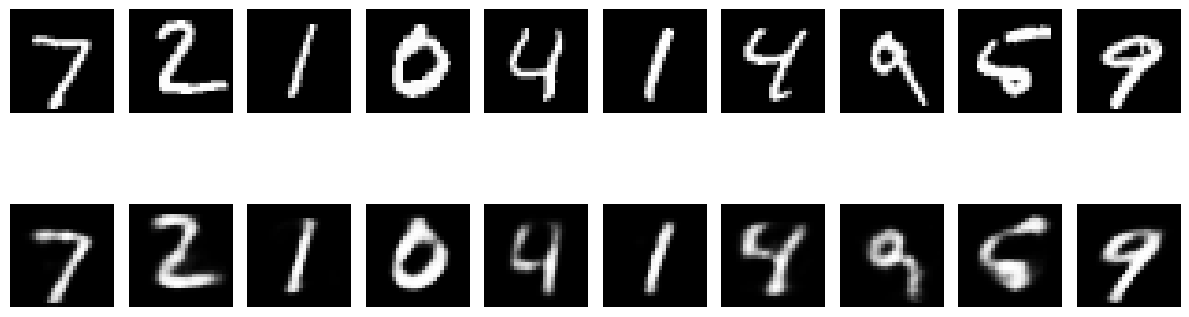

In [15]:
vae.eval()

images, labels = next(iter(test_loader))

images_device = images.to(device)

with torch.no_grad():

    reconstruction, mu, logvar = vae(
        images_device
    )

reconstruction = reconstruction.view(
    -1, 1, 28, 28
).cpu()

plt.figure(figsize=(12, 5))

for i in range(10):

    # Original
    plt.subplot(2, 10, i + 1)

    plt.imshow(
        images[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

    if i == 0:
        plt.ylabel("Original")

    # Reconstruction
    plt.subplot(2, 10, i + 11)

    plt.imshow(
        reconstruction[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

    if i == 0:
        plt.ylabel("VAE")

plt.tight_layout()
plt.show()

Part C — Generate New Images

In [16]:
vae.eval()

num_samples = 20

with torch.no_grad():

    # Random latent vectors
    z = torch.randn(
        num_samples,
        20
    ).to(device)

    generated = vae.decode(z)

generated = generated.view(
    num_samples,
    1,
    28,
    28
).cpu()

Display generated images

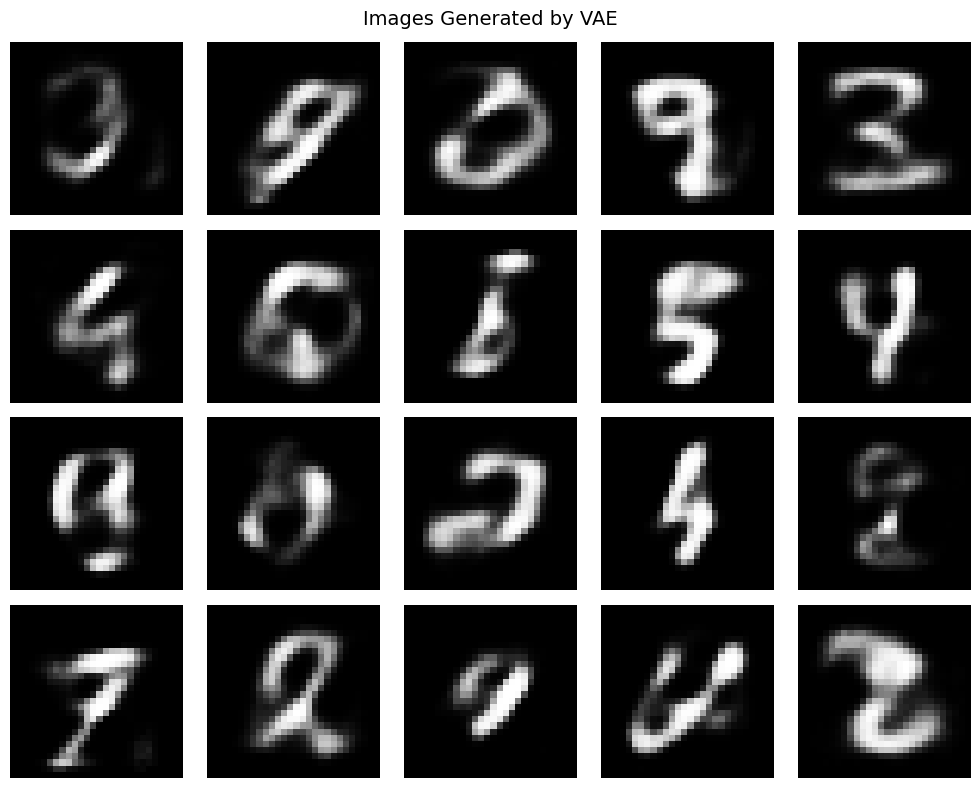

In [17]:
plt.figure(figsize=(10, 8))

for i in range(num_samples):

    plt.subplot(4, 5, i + 1)

    plt.imshow(
        generated[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "Images Generated by VAE",
    fontsize=14
)

plt.tight_layout()
plt.show()

**Train a small autoencoder on MNIST or Fashion-MNIST and show original vs reconstructed images.**

**Dataset: MNIST**

**Autoencoder**

The autoencoder was trained to reconstruct MNIST images. The encoder compresses each 28×28 image into a 20-dimensional latent representation, and the decoder reconstructs the image from this representation. The original and reconstructed images show that the model learns important features of the handwritten digits.

**VAE**

The Variational Autoencoder was trained using a latent distribution represented by a mean and log-variance. The reparameterization trick was used to sample latent vectors during training. After training, random vectors were sampled from a standard normal distribution and passed through the decoder to generate new MNIST-like images.

**How is autoencoder reconstruction different from VAE generation?**

An autoencoder primarily learns to reconstruct a given input. Its encoder maps the input to a latent representation and its decoder uses that representation to reproduce the original image. A VAE also reconstructs inputs during training, but it additionally learns a structured probability distribution in the latent space using the KL-divergence term. This allows us to sample random latent vectors and generate new images that were not directly provided as inputs. Therefore, autoencoder reconstruction focuses on reproducing an input, while VAE generation focuses on producing new samples from the learned latent distribution.

**Observation**

The autoencoder reconstructions generally preserve the main structure of the original digits but may appear slightly blurred. The VAE-generated images resemble handwritten digits, although they may initially be less sharp because the model is small and was trained for only a few epochs.

Problem 3 [10 points] - CONDITIONAL-**GAN**

**Imports and MNIST Dataset**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

print("Training samples:", len(train_dataset))

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.98MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.1MB/s]

Training samples: 60000


Define cGAN Parameters

In [3]:
latent_dim = 100
num_classes = 10
image_size = 28

batch_size = 128
num_epochs = 10

lr = 0.0002
beta1 = 0.5

Conditional Generator

In [4]:
class Generator(nn.Module):

    def __init__(
        self,
        latent_dim=100,
        num_classes=10
    ):

        super(Generator, self).__init__()

        self.label_embedding = nn.Embedding(
            num_classes,
            num_classes
        )

        self.model = nn.Sequential(

            nn.Linear(
                latent_dim + num_classes,
                256
            ),

            nn.LeakyReLU(0.2),

            nn.Linear(
                256,
                512
            ),

            nn.BatchNorm1d(512),

            nn.LeakyReLU(0.2),

            nn.Linear(
                512,
                1024
            ),

            nn.BatchNorm1d(1024),

            nn.LeakyReLU(0.2),

            nn.Linear(
                1024,
                28 * 28
            ),

            nn.Tanh()
        )

    def forward(self, noise, labels):

        label = self.label_embedding(labels)

        x = torch.cat(
            [noise, label],
            dim=1
        )

        image = self.model(x)

        image = image.view(
            image.size(0),
            1,
            28,
            28
        )

        return image

Conditional Discriminator

In [5]:
class Discriminator(nn.Module):

    def __init__(
        self,
        num_classes=10
    ):

        super(Discriminator, self).__init__()

        self.label_embedding = nn.Embedding(
            num_classes,
            num_classes
        )

        self.model = nn.Sequential(

            nn.Linear(
                28 * 28 + num_classes,
                512
            ),

            nn.LeakyReLU(0.2),

            nn.Dropout(0.3),

            nn.Linear(
                512,
                256
            ),

            nn.LeakyReLU(0.2),

            nn.Dropout(0.3),

            nn.Linear(
                256,
                1
            ),

            nn.Sigmoid()
        )

    def forward(self, image, labels):

        image = image.view(
            image.size(0),
            -1
        )

        label = self.label_embedding(labels)

        x = torch.cat(
            [image, label],
            dim=1
        )

        validity = self.model(x)

        return validity

Create Models

In [6]:
generator = Generator(
    latent_dim=latent_dim,
    num_classes=num_classes
).to(device)

discriminator = Discriminator(
    num_classes=num_classes
).to(device)

print("Generator:")
print(generator)

print("\nDiscriminator:")
print(discriminator)

Generator:
Generator(
  (label_embedding): Embedding(10, 10)
  (model): Sequential(
    (0): Linear(in_features=110, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Linear(in_features=512, out_features=1024, bias=True)
    (6): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Linear(in_features=1024, out_features=784, bias=True)
    (9): Tanh()
  )
)

Discriminator:
Discriminator(
  (label_embedding): Embedding(10, 10)
  (model): Sequential(
    (0): Linear(in_features=794, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dro

Loss and Optimizers

In [7]:
criterion = nn.BCELoss()

optimizer_G = optim.Adam(
    generator.parameters(),
    lr=lr,
    betas=(beta1, 0.999)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=lr,
    betas=(beta1, 0.999)
)

**Training the Conditional GAN**

For each batch:

Step 1

Generate fake images.

Step 2

Train Discriminator on:

Real image → 1

Fake image → 0

Step 3

Train Generator to fool the Discriminator:

Fake image → should be classified as 1

In [8]:
g_losses = []
d_losses = []

for epoch in range(num_epochs):

    generator.train()
    discriminator.train()

    running_g_loss = 0.0
    running_d_loss = 0.0

    for real_images, labels in train_loader:

        real_images = real_images.to(device)
        labels = labels.to(device)

        batch_size_current = real_images.size(0)

        # Real and fake targets
        real_targets = torch.ones(
            batch_size_current,
            1,
            device=device
        )

        fake_targets = torch.zeros(
            batch_size_current,
            1,
            device=device
        )

        # =====================================
        # Train Discriminator
        # =====================================

        optimizer_D.zero_grad()

        # Real images
        real_output = discriminator(
            real_images,
            labels
        )

        real_loss = criterion(
            real_output,
            real_targets
        )

        # Generate fake images
        noise = torch.randn(
            batch_size_current,
            latent_dim,
            device=device
        )

        fake_images = generator(
            noise,
            labels
        )

        # Fake images
        fake_output = discriminator(
            fake_images.detach(),
            labels
        )

        fake_loss = criterion(
            fake_output,
            fake_targets
        )

        # Total discriminator loss
        d_loss = (
            real_loss +
            fake_loss
        ) / 2

        d_loss.backward()
        optimizer_D.step()

        # =====================================
        # Train Generator
        # =====================================

        optimizer_G.zero_grad()

        noise = torch.randn(
            batch_size_current,
            latent_dim,
            device=device
        )

        generated_images = generator(
            noise,
            labels
        )

        output = discriminator(
            generated_images,
            labels
        )

        # Generator wants fake images
        # to be classified as real
        g_loss = criterion(
            output,
            real_targets
        )

        g_loss.backward()
        optimizer_G.step()

        running_d_loss += d_loss.item()
        running_g_loss += g_loss.item()

    epoch_d_loss = (
        running_d_loss /
        len(train_loader)
    )

    epoch_g_loss = (
        running_g_loss /
        len(train_loader)
    )

    d_losses.append(epoch_d_loss)
    g_losses.append(epoch_g_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"D Loss: {epoch_d_loss:.4f} | "
        f"G Loss: {epoch_g_loss:.4f}"
    )

Epoch [1/10] D Loss: 0.6434 | G Loss: 0.8515
Epoch [2/10] D Loss: 0.6189 | G Loss: 0.9823
Epoch [3/10] D Loss: 0.6108 | G Loss: 1.0139
Epoch [4/10] D Loss: 0.6028 | G Loss: 1.0325
Epoch [5/10] D Loss: 0.6008 | G Loss: 1.0328
Epoch [6/10] D Loss: 0.6036 | G Loss: 1.0150
Epoch [7/10] D Loss: 0.6076 | G Loss: 0.9905
Epoch [8/10] D Loss: 0.6108 | G Loss: 0.9755
Epoch [9/10] D Loss: 0.6215 | G Loss: 0.9450
Epoch [10/10] D Loss: 0.6312 | G Loss: 0.9015


Plot Generator and Discriminator Loss

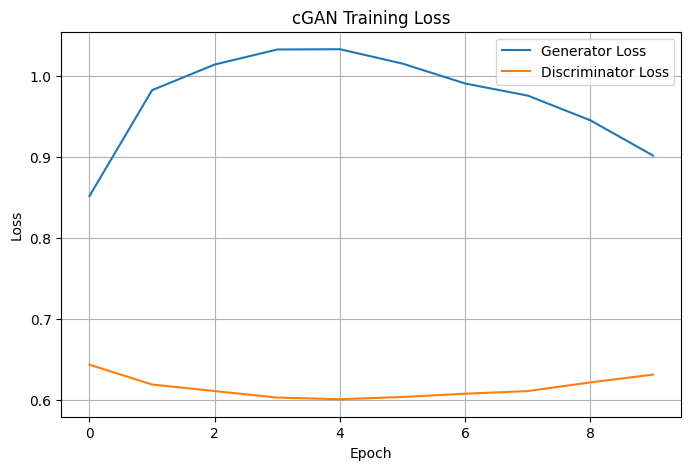

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(
    g_losses,
    label="Generator Loss"
)

plt.plot(
    d_losses,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("cGAN Training Loss")

plt.legend()
plt.grid()

plt.show()

Generate Specific Digits

In [10]:
generator.eval()

selected_labels = torch.tensor(
    [
        0, 1, 2, 3, 4,
        5, 6, 7, 8, 9
    ],
    device=device
)

samples_per_class = 5

all_labels = selected_labels.repeat_interleave(
    samples_per_class
)

noise = torch.randn(
    len(all_labels),
    latent_dim,
    device=device
)

with torch.no_grad():

    generated_images = generator(
        noise,
        all_labels
    )

generated_images = generated_images.cpu()

Display Generated Digits

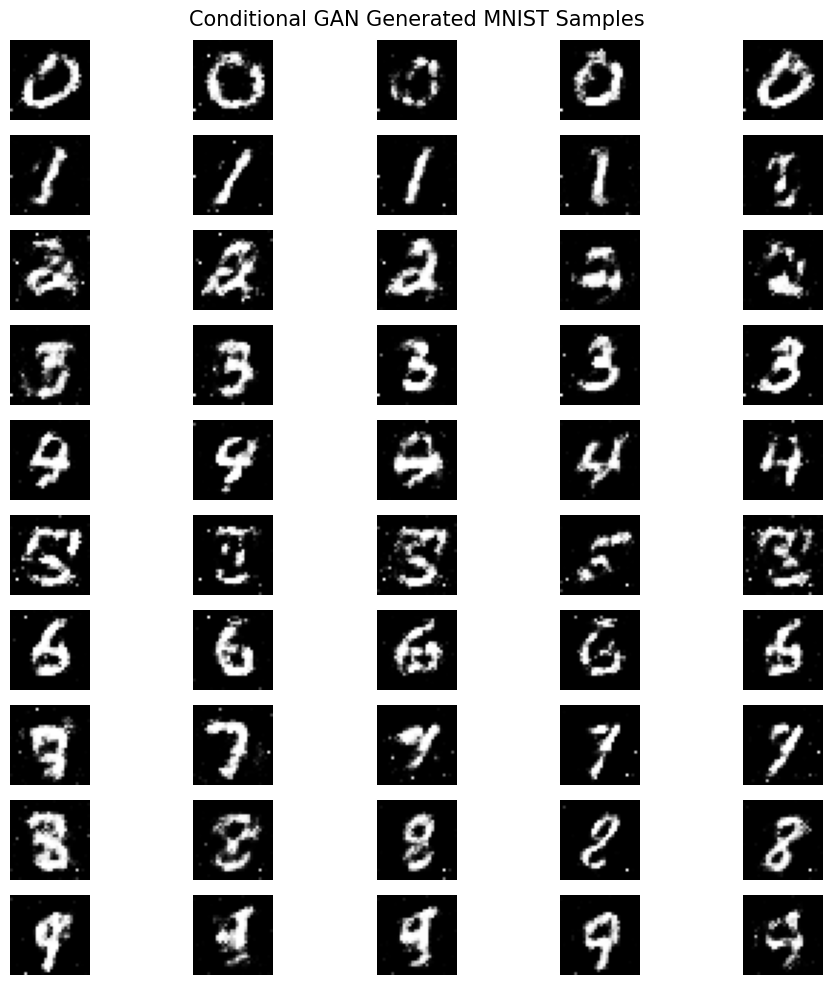

In [11]:
plt.figure(figsize=(10, 10))

for i in range(len(generated_images)):

    plt.subplot(
        10,
        samples_per_class,
        i + 1
    )

    image = generated_images[i].squeeze()

    # Convert [-1,1] back to [0,1]
    image = (image + 1) / 2

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.axis("off")

    if i % samples_per_class == 0:
        plt.ylabel(
            str(all_labels[i].item()),
            fontsize=12
        )

plt.suptitle(
    "Conditional GAN Generated MNIST Samples",
    fontsize=15
)

plt.tight_layout()
plt.show()

Generate Only Selected Digits

In [12]:
chosen_digits = [0, 3, 5, 8]

samples_per_digit = 8

labels_for_generation = torch.tensor(
    chosen_digits,
    device=device
).repeat_interleave(
    samples_per_digit
)

noise = torch.randn(
    len(labels_for_generation),
    latent_dim,
    device=device
)

with torch.no_grad():

    samples = generator(
        noise,
        labels_for_generation
    )

samples = samples.cpu()

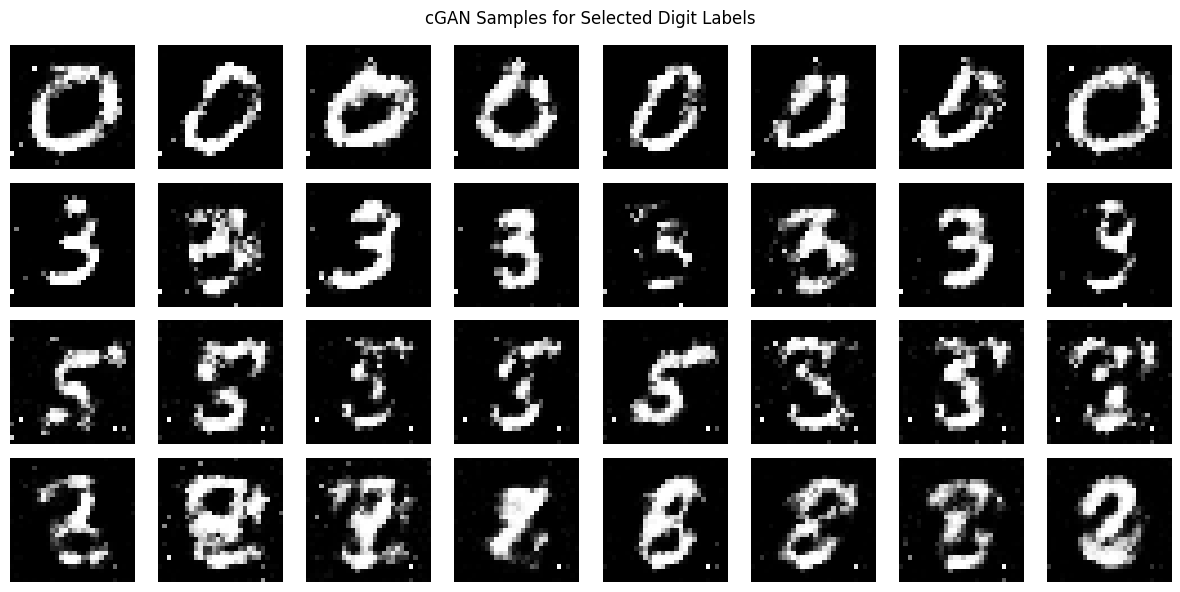

In [13]:
plt.figure(figsize=(12, 6))

for i in range(len(samples)):

    plt.subplot(
        len(chosen_digits),
        samples_per_digit,
        i + 1
    )

    image = samples[i].squeeze()

    image = (image + 1) / 2

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.axis("off")

    if i % samples_per_digit == 0:

        digit = chosen_digits[
            i // samples_per_digit
        ]

        plt.ylabel(
            str(digit),
            fontsize=12
        )

plt.suptitle(
    "cGAN Samples for Selected Digit Labels"
)

plt.tight_layout()
plt.show()

**Train a small conditional GAN on MNIST.**

**Dataset: MNIST**

**Model: Conditional Generative Adversarial Network (cGAN)**

The cGAN was trained using MNIST images and their corresponding digit labels. The Generator receives a random noise vector together with a digit label and generates an image conditioned on that label. The Discriminator receives both an image and its digit label and determines whether the image is real or generated.

**Generate and display samples for several chosen digit labels.**

The model was used to generate samples for several digit labels, including digits 0 through 9. The generated images demonstrate that the Generator can use the supplied class label to produce images corresponding to the requested digit.

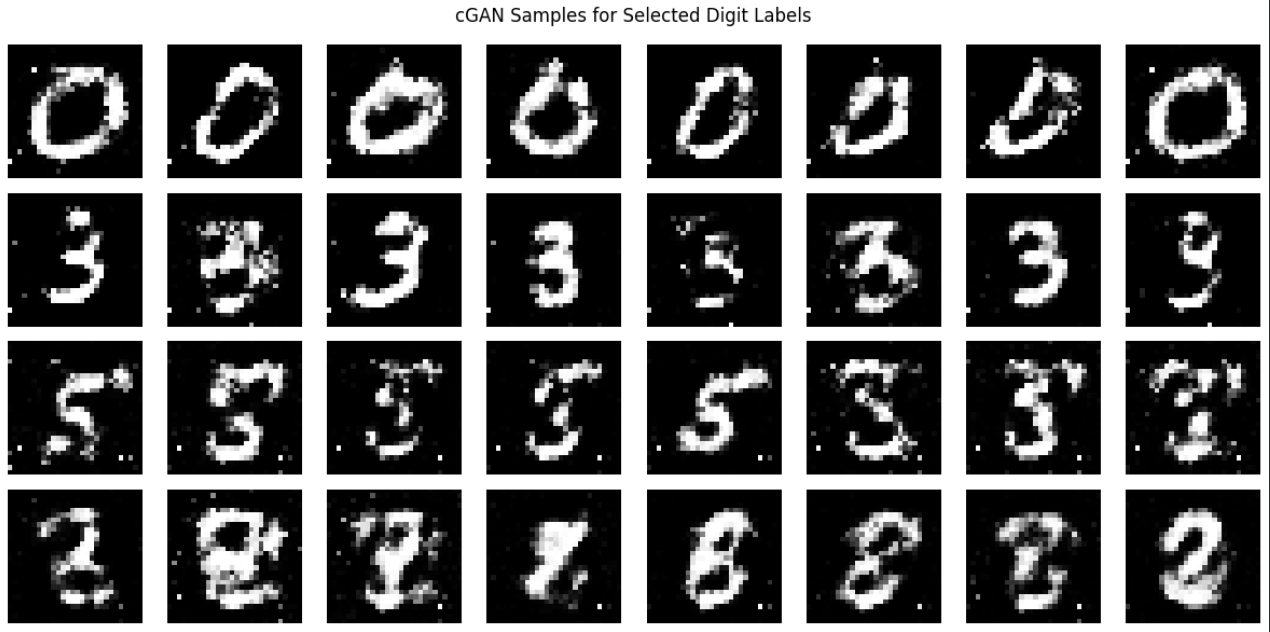

**Do the generated samples look diverse?**

The generated samples show variation in the appearance, shape, thickness, and style of the digits. Different random noise vectors can produce different samples for the same digit label. The amount of diversity depends on the training of the GAN and the number of epochs used.

Is there any evidence of mode collapse?

There is no strong evidence of severe mode collapse if the generated images for the same digit are visibly different from one another. However, some generated samples may look similar because the model is relatively small and was trained for a limited number of epochs. Severe mode collapse would be indicated if the Generator repeatedly produced almost identical images regardless of the random noise vector.

Conclusion

The conditional GAN successfully learns the relationship between digit labels and image generation. By providing a specific label to the Generator, it can generate MNIST-like images corresponding to that digit. The generated samples also demonstrate whether the model has learned a diverse representation of each digit class.

**Problem 4 [10 points] - RNN/LSTM/GRU**

**1. Generate the noisy sine-wave dataset**

Imports

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset, DataLoader

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


Generate noisy sine wave

In [15]:
np.random.seed(42)
torch.manual_seed(42)

# Total number of points
num_points = 3000

# Time values
t = np.linspace(
    0,
    100,
    num_points
)

# Clean sine wave
clean_signal = np.sin(t)

# Random Gaussian noise
noise = np.random.normal(
    0,
    0.1,
    num_points
)

# Noisy signal
signal = clean_signal + noise

print("Number of points:", len(signal))

Number of points: 3000


Visualize the sequence

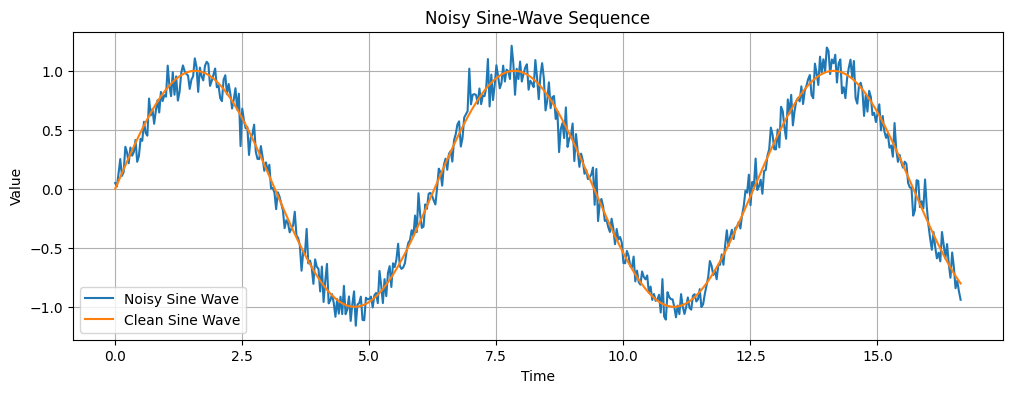

In [16]:
plt.figure(figsize=(12, 4))

plt.plot(
    t[:500],
    signal[:500],
    label="Noisy Sine Wave"
)

plt.plot(
    t[:500],
    clean_signal[:500],
    label="Clean Sine Wave"
)

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Noisy Sine-Wave Sequence")

plt.legend()
plt.grid()

plt.show()

**2. Create sequences for next-step prediction**

Create sequences

In [17]:
sequence_length = 50

X = []
y = []

for i in range(
    len(signal) - sequence_length
):

    X.append(
        signal[
            i:i + sequence_length
        ]
    )

    y.append(
        signal[
            i + sequence_length
        ]
    )

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2950, 50)
y shape: (2950,)


**3. Train/Test Split**

In [18]:
train_size = int(
    0.8 * len(X)
)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 2360
Testing samples: 590


**4. Convert to PyTorch tensors**

In [19]:
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
).unsqueeze(-1)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
).unsqueeze(-1)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
).unsqueeze(-1)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.float32
).unsqueeze(-1)

print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)

X_train: torch.Size([2360, 50, 1])
y_train: torch.Size([2360, 1])


DataLoaders

In [20]:
batch_size = 64

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

5. Create a Common RNN Model

We want to compare:


Vanilla RNN

LSTM

GRU

using essentially the same architecture and hyperparameters.

Define the model

In [21]:
class SequenceModel(nn.Module):

    def __init__(
        self,
        model_type="RNN",
        input_size=1,
        hidden_size=64,
        num_layers=1
    ):

        super(SequenceModel, self).__init__()

        self.model_type = model_type

        if model_type == "RNN":

            self.rnn = nn.RNN(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True
            )

        elif model_type == "LSTM":

            self.rnn = nn.LSTM(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True
            )

        elif model_type == "GRU":

            self.rnn = nn.GRU(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True
            )

        else:

            raise ValueError(
                "model_type must be RNN, LSTM, or GRU"
            )

        self.fc = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):

        output, _ = self.rnn(x)

        # Take output from final time step
        last_output = output[:, -1, :]

        prediction = self.fc(
            last_output
        )

        return prediction

Training function

In [22]:
def train_model(
    model,
    train_loader,
    test_loader,
    epochs=20,
    learning_rate=0.001
):

    criterion = nn.MSELoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    train_losses = []

    test_losses = []

    for epoch in range(epochs):

        # ==========================
        # Training
        # ==========================

        model.train()

        running_train_loss = 0.0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            predictions = model(
                X_batch
            )

            loss = criterion(
                predictions,
                y_batch
            )

            loss.backward()

            optimizer.step()

            running_train_loss += loss.item()

        train_loss = (
            running_train_loss /
            len(train_loader)
        )

        # ==========================
        # Testing
        # ==========================

        model.eval()

        running_test_loss = 0.0

        with torch.no_grad():

            for X_batch, y_batch in test_loader:

                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                predictions = model(
                    X_batch
                )

                loss = criterion(
                    predictions,
                    y_batch
                )

                running_test_loss += loss.item()

        test_loss = (
            running_test_loss /
            len(test_loader)
        )

        train_losses.append(
            train_loss
        )

        test_losses.append(
            test_loss
        )

        if (epoch + 1) % 5 == 0:

            print(
                f"Epoch [{epoch+1}/{epochs}] "
                f"Train Loss: {train_loss:.6f} "
                f"Test Loss: {test_loss:.6f}"
            )

    return train_losses, test_losses

7. Train Vanilla RNN

In [23]:
rnn_model = SequenceModel(
    model_type="RNN",
    input_size=1,
    hidden_size=64,
    num_layers=1
).to(device)

print(rnn_model)

SequenceModel(
  (rnn): RNN(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [24]:
rnn_train_losses, rnn_test_losses = train_model(
    rnn_model,
    train_loader,
    test_loader,
    epochs=20,
    learning_rate=0.001
)

Epoch [5/20] Train Loss: 0.014665 Test Loss: 0.014578
Epoch [10/20] Train Loss: 0.012967 Test Loss: 0.013039
Epoch [15/20] Train Loss: 0.012615 Test Loss: 0.012996
Epoch [20/20] Train Loss: 0.012704 Test Loss: 0.012721


8. Train LSTM

In [25]:
lstm_model = SequenceModel(
    model_type="LSTM",
    input_size=1,
    hidden_size=64,
    num_layers=1
).to(device)

print(lstm_model)

SequenceModel(
  (rnn): LSTM(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [26]:
lstm_train_losses, lstm_test_losses = train_model(
    lstm_model,
    train_loader,
    test_loader,
    epochs=20,
    learning_rate=0.001
)

Epoch [5/20] Train Loss: 0.013524 Test Loss: 0.012944
Epoch [10/20] Train Loss: 0.012642 Test Loss: 0.012637
Epoch [15/20] Train Loss: 0.012737 Test Loss: 0.012483
Epoch [20/20] Train Loss: 0.011961 Test Loss: 0.011667


9. Train GRU

In [27]:
gru_model = SequenceModel(
    model_type="GRU",
    input_size=1,
    hidden_size=64,
    num_layers=1
).to(device)

print(gru_model)

SequenceModel(
  (rnn): GRU(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [28]:
gru_train_losses, gru_test_losses = train_model(
    gru_model,
    train_loader,
    test_loader,
    epochs=20,
    learning_rate=0.001
)

Epoch [5/20] Train Loss: 0.012418 Test Loss: 0.011931
Epoch [10/20] Train Loss: 0.012074 Test Loss: 0.011658
Epoch [15/20] Train Loss: 0.011701 Test Loss: 0.011305
Epoch [20/20] Train Loss: 0.011680 Test Loss: 0.011113


10. Compare Final Losses

In [29]:
final_rnn_loss = rnn_test_losses[-1]
final_lstm_loss = lstm_test_losses[-1]
final_gru_loss = gru_test_losses[-1]

print(
    f"Final RNN Test Loss:  {final_rnn_loss:.6f}"
)

print(
    f"Final LSTM Test Loss: {final_lstm_loss:.6f}"
)

print(
    f"Final GRU Test Loss:  {final_gru_loss:.6f}"
)

Final RNN Test Loss:  0.012721
Final LSTM Test Loss: 0.011667
Final GRU Test Loss:  0.011113


11. Plot Test Loss Comparison

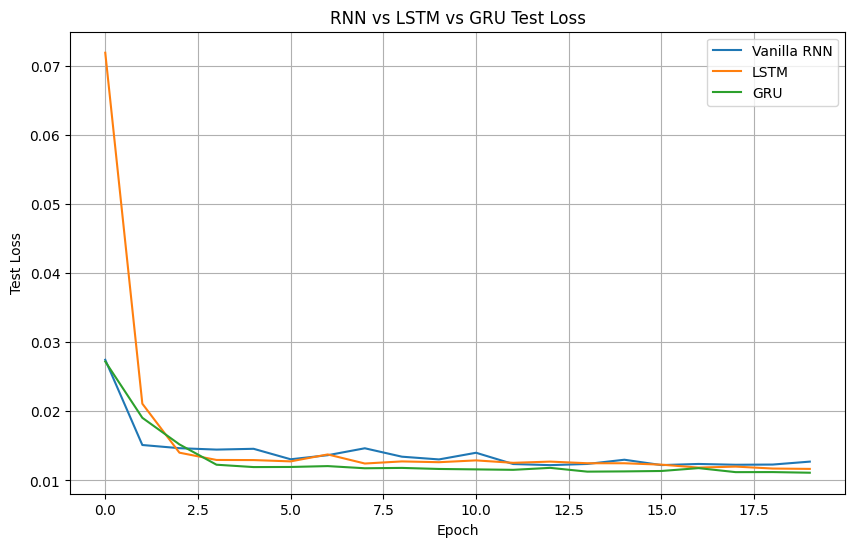

In [30]:
plt.figure(figsize=(10, 6))

plt.plot(
    rnn_test_losses,
    label="Vanilla RNN"
)

plt.plot(
    lstm_test_losses,
    label="LSTM"
)

plt.plot(
    gru_test_losses,
    label="GRU"
)

plt.xlabel("Epoch")
plt.ylabel("Test Loss")

plt.title(
    "RNN vs LSTM vs GRU Test Loss"
)

plt.legend()
plt.grid()

plt.show()

12. Visualize Predictions

In [31]:
rnn_model.eval()
lstm_model.eval()
gru_model.eval()

with torch.no_grad():

    X_sample = X_test_tensor[:200].to(device)

    rnn_predictions = rnn_model(
        X_sample
    ).cpu().numpy()

    lstm_predictions = lstm_model(
        X_sample
    ).cpu().numpy()

    gru_predictions = gru_model(
        X_sample
    ).cpu().numpy()

actual_values = y_test[:200]

RNN predictions

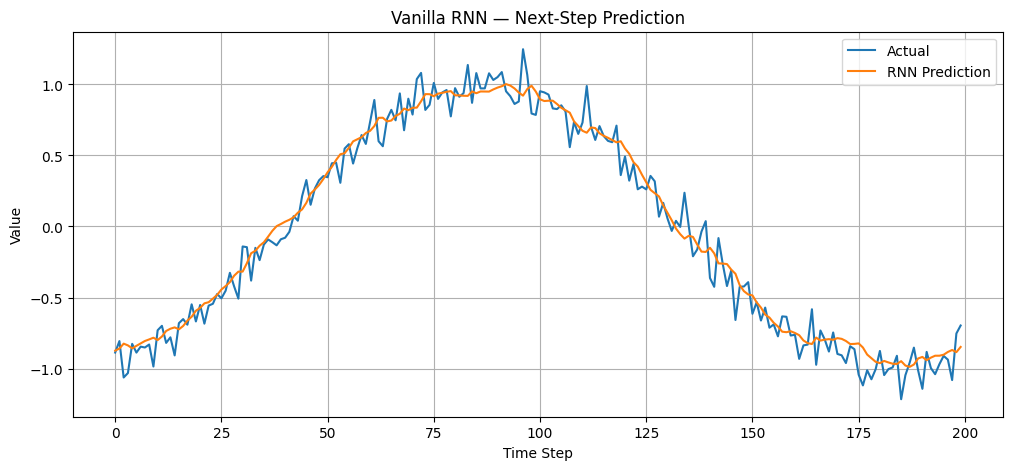

In [32]:
plt.figure(figsize=(12, 5))

plt.plot(
    actual_values,
    label="Actual"
)

plt.plot(
    rnn_predictions,
    label="RNN Prediction"
)

plt.xlabel("Time Step")
plt.ylabel("Value")

plt.title(
    "Vanilla RNN — Next-Step Prediction"
)

plt.legend()
plt.grid()

plt.show()

LSTM predictions

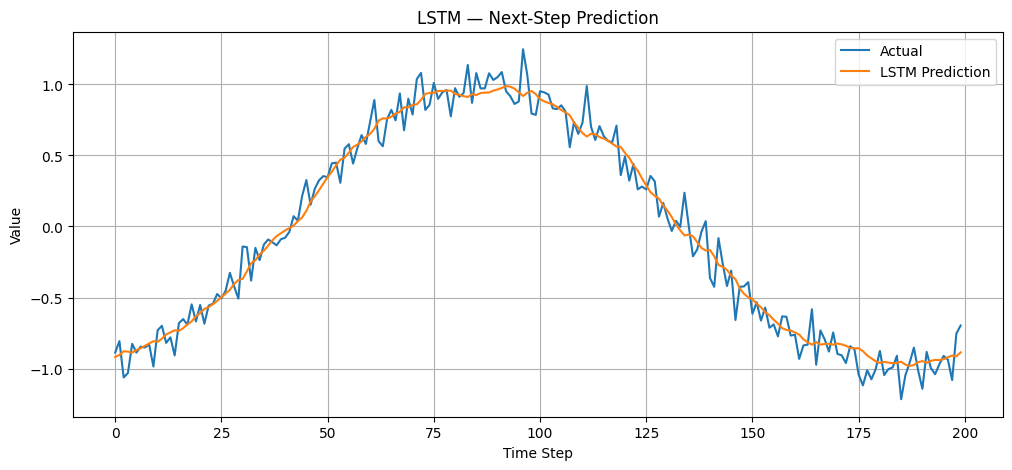

In [33]:
plt.figure(figsize=(12, 5))

plt.plot(
    actual_values,
    label="Actual"
)

plt.plot(
    lstm_predictions,
    label="LSTM Prediction"
)

plt.xlabel("Time Step")
plt.ylabel("Value")

plt.title(
    "LSTM — Next-Step Prediction"
)

plt.legend()
plt.grid()

plt.show()

GRU predictions

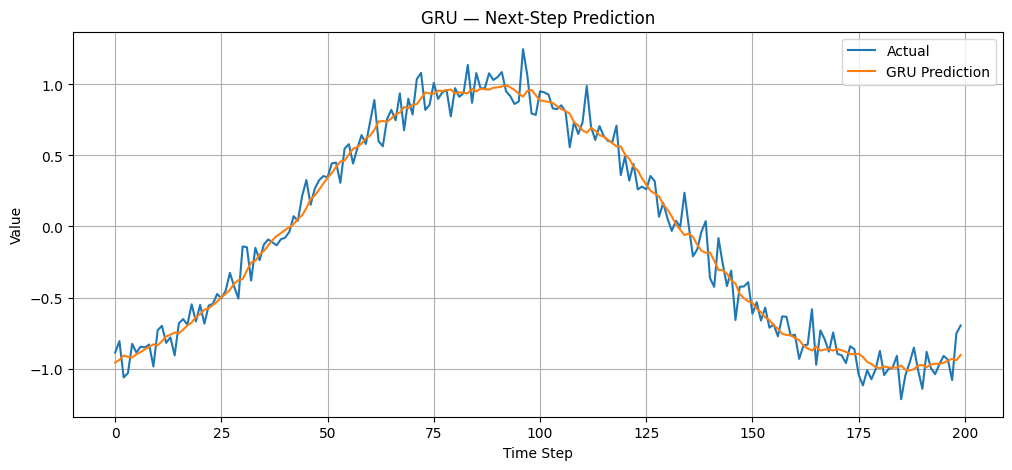

In [34]:
plt.figure(figsize=(12, 5))

plt.plot(
    actual_values,
    label="Actual"
)

plt.plot(
    gru_predictions,
    label="GRU Prediction"
)

plt.xlabel("Time Step")
plt.ylabel("Value")

plt.title(
    "GRU — Next-Step Prediction"
)

plt.legend()
plt.grid()

plt.show()

13. Automatically Determine the Best Model

In [35]:
results = {
    "Vanilla RNN": final_rnn_loss,
    "LSTM": final_lstm_loss,
    "GRU": final_gru_loss
}

best_model = min(
    results,
    key=results.get
)

print("Final Test Losses:")

for model_name, loss in results.items():

    print(
        f"{model_name}: {loss:.6f}"
    )

print(
    f"\nBest performing model: {best_model}"
)

Final Test Losses:
Vanilla RNN: 0.012721
LSTM: 0.011667
GRU: 0.011113

Best performing model: GRU


• Create a noisy sine-wave sequence for next-step prediction.

• Train a vanilla RNN, an LSTM, and a GRU using the same basic settings.

• Report the final validation or test loss for each model.

• Answer in a markdown cell: Which performed best? Give one reason LSTMs or GRUs can handle longer-term information better than a vanilla RNN. State one structural difference between a GRU and an LSTM.

**Task: Next-step prediction on a noisy sine-wave sequence.**

The noisy sine-wave sequence was divided into input sequences of 50 time steps. The objective was to use these 50 previous values to predict the next value. The same dataset split, hidden size, optimizer, learning rate, batch size, and number of epochs were used for the vanilla RNN, LSTM, and GRU to make the comparison fair.

Final Test Loss

Model	Final               Test Loss

Vanilla RNN	 :             0.012721

LSTM	   :                 0.011667

GRU	     :                0.011113

**Which model performed best?**

Based on the final test loss, GRU(0.011113) performed best because it achieved the lowest test loss among the three models.

The exact result depends on the training run and the generated noisy sequence. Therefore, the model with the lowest loss in the experiment should be reported as the best-performing model.

**Why can LSTMs or GRUs handle longer-term information better than a vanilla RNN?**

LSTMs and GRUs use gating mechanisms that control how information is stored, updated, and forgotten. These mechanisms help preserve useful information across many time steps and reduce the effect of the vanishing-gradient problem that can make it difficult for a vanilla RNN to learn long-term dependencies.

**One structural difference between a GRU and an LSTM**

An LSTM maintains a separate cell state in addition to its hidden state and uses three main gates: forget, input, and output gates. A GRU does not maintain a separate cell state and uses two main gates: update and reset gates. Therefore, a GRU has a simpler architecture and generally fewer parameters than an LSTM.

**Problem 5 [20 points] - ATTENTION/POSITIONAL-ENCODING/VISION-TRANSFORMER**

**Part A — Scaled Dot-Product Self-Attention**

Q ─────┐
       │
K ─────┼──> QKᵀ / √dₖ ──> Softmax ──> Attention Weights
       │                                      │
V ─────┴──────────────────────────────────────┘
                                               ↓
                                        Attention Output

Imports

In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cu128


Create Q, K and V

In [37]:
torch.manual_seed(42)

# Number of tokens
seq_len = 6

# Dimension of each Q/K/V vector
d_k = 8

Q = torch.randn(
    seq_len,
    d_k
)

K = torch.randn(
    seq_len,
    d_k
)

V = torch.randn(
    seq_len,
    d_k
)

print("Q shape:", Q.shape)
print("K shape:", K.shape)
print("V shape:", V.shape)

Q shape: torch.Size([6, 8])
K shape: torch.Size([6, 8])
V shape: torch.Size([6, 8])


Calculate Attention Scores


In [38]:
scores = torch.matmul(
    Q,
    K.T
)

print("Raw attention scores:")
print(scores)

Raw attention scores:
tensor([[-4.3623, -8.6428,  3.4281,  2.0828, -0.8739, -2.4794],
        [-1.4130,  1.1963,  0.3635,  1.4369, -0.7406, -0.7301],
        [-1.4376,  1.4581,  2.1911, -4.3638,  1.6413,  4.3807],
        [-1.5380,  0.7021,  6.2868,  0.8119, -2.3700,  0.9370],
        [ 2.3842,  0.8380, -3.4622,  0.8643, -0.1686,  0.4967],
        [ 4.8983,  6.6989, -3.8462,  1.4792,  0.1735, -2.5245]])


Scale the Scores

In [39]:
scaled_scores = scores / np.sqrt(d_k)

print("Scaled attention scores:")
print(scaled_scores)

Scaled attention scores:
tensor([[-1.5423, -3.0557,  1.2120,  0.7364, -0.3090, -0.8766],
        [-0.4996,  0.4229,  0.1285,  0.5080, -0.2619, -0.2581],
        [-0.5083,  0.5155,  0.7747, -1.5428,  0.5803,  1.5488],
        [-0.5437,  0.2482,  2.2227,  0.2870, -0.8379,  0.3313],
        [ 0.8429,  0.2963, -1.2241,  0.3056, -0.0596,  0.1756],
        [ 1.7318,  2.3684, -1.3598,  0.5230,  0.0613, -0.8925]])


Apply Softmax

In [40]:
attention_weights = F.softmax(
    scaled_scores,
    dim=-1
)

print("Attention weights:")
print(attention_weights)

print(
    "\nRow sums:",
    attention_weights.sum(dim=-1)
)

Attention weights:
tensor([[0.0312, 0.0069, 0.4898, 0.3044, 0.1070, 0.0607],
        [0.0937, 0.2358, 0.1756, 0.2567, 0.1189, 0.1193],
        [0.0539, 0.1501, 0.1946, 0.0192, 0.1602, 0.4220],
        [0.0407, 0.0899, 0.6478, 0.0935, 0.0304, 0.0977],
        [0.3117, 0.1804, 0.0394, 0.1821, 0.1264, 0.1599],
        [0.2861, 0.5408, 0.0130, 0.0854, 0.0538, 0.0207]])

Row sums: tensor([1., 1., 1., 1., 1., 1.])


Calculate Attention Output

In [41]:
attention_output = torch.matmul(
    attention_weights,
    V
)

print("Attention output:")
print(attention_output)

print(
    "\nOutput shape:",
    attention_output.shape
)

Attention output:
tensor([[-0.5211,  0.1530, -0.4892,  0.4037,  0.6735,  0.4128,  0.0903,  0.4680],
        [-0.1723,  0.3896, -0.2885,  0.3008,  0.4702,  0.7758,  0.2121,  0.2290],
        [ 0.3441,  0.2940, -1.0031,  0.3453,  0.0564,  0.9448, -0.1894,  0.4017],
        [-0.8937,  0.0763, -0.5274,  0.4538,  0.5819,  0.3797, -0.1886,  0.4145],
        [-0.4488,  0.4586, -0.1523,  0.2043,  0.3984,  0.8489,  0.4210,  0.0753],
        [-0.7107,  0.6209,  0.3322,  0.1346,  0.4145,  0.9952,  0.3820, -0.2068]])

Output shape: torch.Size([6, 8])


Plot Attention Heatmap

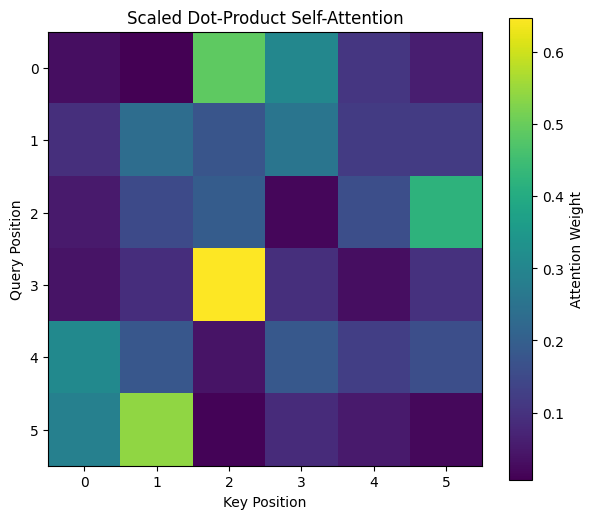

In [42]:
plt.figure(figsize=(7, 6))

plt.imshow(
    attention_weights.detach().numpy(),
    cmap="viridis"
)

plt.colorbar(
    label="Attention Weight"
)

plt.xlabel("Key Position")
plt.ylabel("Query Position")

plt.title(
    "Scaled Dot-Product Self-Attention"
)

plt.xticks(range(seq_len))
plt.yticks(range(seq_len))

plt.show()

**Part B — Sinusoidal Positional Encoding**

Transformers don't inherently know the order of tokens.


Positional Encoding Function

In [43]:
def sinusoidal_positional_encoding(
    seq_len,
    d_model
):

    position = torch.arange(
        seq_len,
        dtype=torch.float32
    ).unsqueeze(1)

    div_term = torch.exp(
        torch.arange(
            0,
            d_model,
            2,
            dtype=torch.float32
        )
        * (
            -np.log(10000.0)
            / d_model
        )
    )

    pe = torch.zeros(
        seq_len,
        d_model
    )

    pe[:, 0::2] = torch.sin(
        position * div_term
    )

    pe[:, 1::2] = torch.cos(
        position * div_term
    )

    return pe

Generate Positional Encoding

In [44]:
seq_len = 50
d_model = 32

pe = sinusoidal_positional_encoding(
    seq_len,
    d_model
)

print("Positional encoding shape:")
print(pe.shape)

Positional encoding shape:
torch.Size([50, 32])


Visualize Positional Encoding

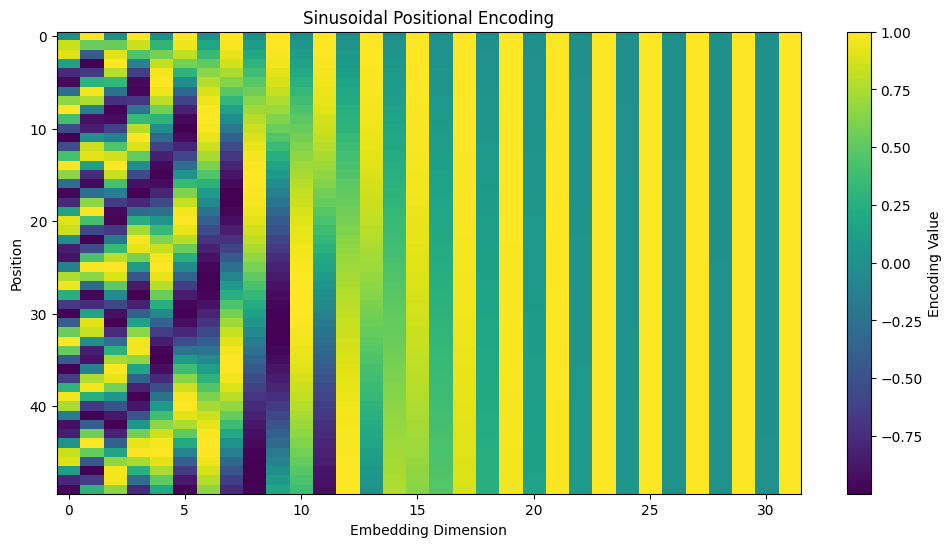

In [45]:
plt.figure(figsize=(12, 6))

plt.imshow(
    pe.numpy(),
    aspect="auto",
    cmap="viridis"
)

plt.colorbar(
    label="Encoding Value"
)

plt.xlabel("Embedding Dimension")
plt.ylabel("Position")

plt.title(
    "Sinusoidal Positional Encoding"
)

plt.show()

**Part C — Vision Transformer on Fashion-MNIST**

Load Fashion-MNIST

In [46]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

print(
    "Training samples:",
    len(train_dataset)
)

print(
    "Testing samples:",
    len(test_dataset)
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.29MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 145kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.68MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.6MB/s]

Training samples: 60000
Testing samples: 10000


Define the Vision Transformer

In [47]:
class SmallViT(nn.Module):

    def __init__(
        self,
        image_size=28,
        patch_size=7,
        num_classes=10,
        embed_dim=64,
        num_heads=4,
        num_layers=2,
        mlp_dim=128,
        dropout=0.1
    ):

        super(SmallViT, self).__init__()

        self.image_size = image_size
        self.patch_size = patch_size

        # Number of patches
        self.num_patches = (
            image_size // patch_size
        ) ** 2

        # Flattened patch size
        patch_dim = (
            patch_size *
            patch_size
        )

        # Convert each patch to embedding
        self.patch_embedding = nn.Linear(
            patch_dim,
            embed_dim
        )

        # Learnable CLS token
        self.cls_token = nn.Parameter(
            torch.randn(
                1,
                1,
                embed_dim
            )
        )

        # Learnable positional embeddings
        self.pos_embedding = nn.Parameter(
            torch.randn(
                1,
                self.num_patches + 1,
                embed_dim
            )
        )

        self.dropout = nn.Dropout(
            dropout
        )

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=mlp_dim,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(
                embed_dim,
                num_classes
            )
        )

    def forward(self, x):

        batch_size = x.size(0)

        # ---------------------------------
        # Split image into patches
        # ---------------------------------

        patches = x.unfold(
            2,
            self.patch_size,
            self.patch_size
        ).unfold(
            3,
            self.patch_size,
            self.patch_size
        )

        # Shape:
        # batch, channel, rows, cols,
        # patch_height, patch_width

        # Rearrange
        patches = patches.permute(
            0,
            2,
            3,
            1,
            4,
            5
        )

        # Flatten patches
        patches = patches.reshape(
            batch_size,
            self.num_patches,
            -1
        )

        # ---------------------------------
        # Patch embedding
        # ---------------------------------

        x = self.patch_embedding(
            patches
        )

        # ---------------------------------
        # Add CLS token
        # ---------------------------------

        cls_tokens = self.cls_token.expand(
            batch_size,
            -1,
            -1
        )

        x = torch.cat(
            [cls_tokens, x],
            dim=1
        )

        # ---------------------------------
        # Add positional embedding
        # ---------------------------------

        x = x + self.pos_embedding

        x = self.dropout(x)

        # ---------------------------------
        # Transformer
        # ---------------------------------

        x = self.transformer(x)

        # ---------------------------------
        # Classification
        # ---------------------------------

        cls_output = x[:, 0]

        output = self.classifier(
            cls_output
        )

        return output

Create ViT

In [48]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

vit_model = SmallViT(
    image_size=28,
    patch_size=7,
    num_classes=10,
    embed_dim=64,
    num_heads=4,
    num_layers=2,
    mlp_dim=128,
    dropout=0.1
).to(device)

print(vit_model)

SmallViT(
  (patch_embedding): Linear(in_features=49, out_features=64, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=64, out_features=10, bias=True)
  )
)


number of parameters

In [49]:
vit_params = sum(
    p.numel()
    for p in vit_model.parameters()
    if p.requires_grad
)

print(
    "Trainable parameters:",
    vit_params
)

Trainable parameters: 72074


Loss and Optimizer

In [50]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    vit_model.parameters(),
    lr=0.001,
    weight_decay=0.0001
)

Train the Vision Transformer

In [51]:
num_epochs = 5

vit_train_losses = []

for epoch in range(num_epochs):

    vit_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = vit_model(
            images
        )

        loss = criterion(
            outputs,
            labels
        )

        # Backpropagation
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # Statistics
        running_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    epoch_loss = (
        running_loss /
        len(train_loader)
    )

    epoch_accuracy = (
        100 * correct / total
    )

    vit_train_losses.append(
        epoch_loss
    )

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/5] Loss: 0.8972 Accuracy: 66.90%
Epoch [2/5] Loss: 0.5780 Accuracy: 78.55%
Epoch [3/5] Loss: 0.5093 Accuracy: 81.36%
Epoch [4/5] Loss: 0.4709 Accuracy: 82.70%
Epoch [5/5] Loss: 0.4459 Accuracy: 83.51%


Plot ViT Training Loss

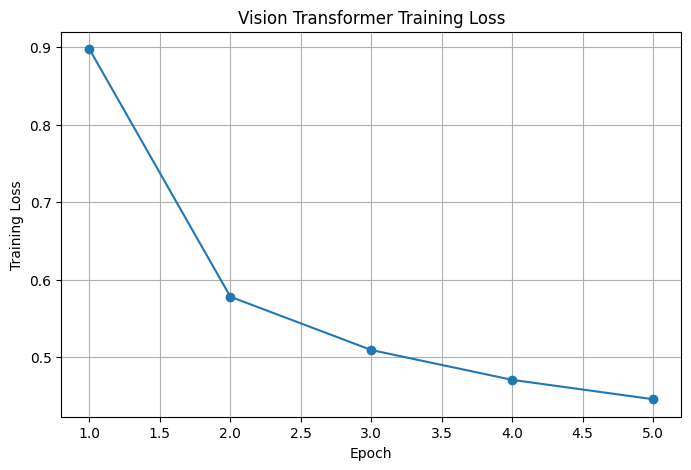

In [52]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    vit_train_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.title(
    "Vision Transformer Training Loss"
)

plt.grid()

plt.show()

Evaluate Test Accuracy

In [53]:
vit_model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = vit_model(
            images
        )

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

vit_test_accuracy = (
    100 * correct / total
)

print(
    f"Vision Transformer "
    f"Test Accuracy: "
    f"{vit_test_accuracy:.2f}%"
)

Vision Transformer Test Accuracy: 83.58%


Show ViT Predictions

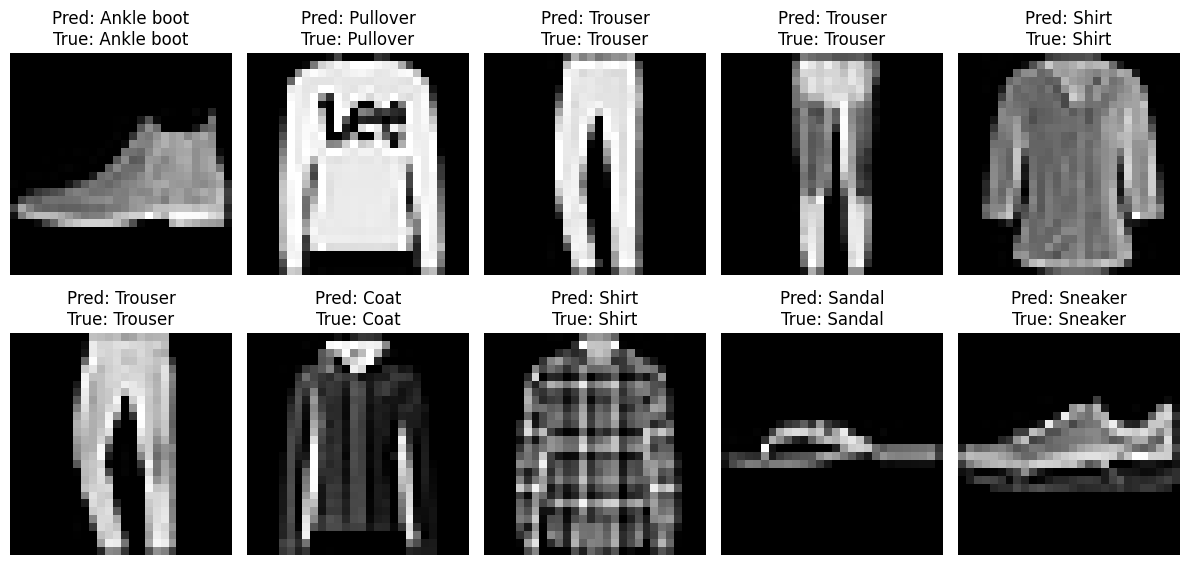

In [54]:
vit_model.eval()

images, labels = next(
    iter(test_loader)
)

images_device = images.to(device)

with torch.no_grad():

    outputs = vit_model(
        images_device
    )

predictions = outputs.argmax(
    dim=1
).cpu()

classes = train_dataset.classes

plt.figure(figsize=(12, 6))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        images[i].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Pred: {classes[predictions[i]]}\n"
        f"True: {classes[labels[i]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

**Scaled Dot-Product Self-Attention**

The scaled dot-product attention was calculated using:

softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V
]

Small Q, K, and V tensors were created and the resulting attention-weight matrix was visualized using a heatmap.

**Why are attention scores divided by √dₖ?**

The dot products between Q and K can become large when the key/query dimension increases. Large values can cause the softmax function to become very concentrated, which can result in very small gradients and unstable learning. Dividing the scores by √dₖ keeps the values at a suitable scale before applying softmax and helps stabilize training.

**What does the attention heatmap show?**

The attention heatmap shows the attention weights between query and key positions. Each row corresponds to a query position and each column corresponds to a key position. A larger value indicates that the query is giving greater importance to that key when computing its attention output.

**Sinusoidal Positional Encoding**

Sinusoidal positional encoding was generated using sine and cosine functions and visualized as a heatmap. Positional encoding provides information about the position of each token or patch because the self-attention mechanism itself does not inherently encode sequence or spatial order.

**Vision Transformer Results**

Dataset: Fashion-MNIST

Patch Size: 7 × 7

Number of Image Patches: 16

Embedding Dimension: 64

Transformer Layers: 2

Attention Heads: 4

Test Accuracy: 83.58%

**One advantage of a Vision Transformer compared with a CNN**

A Vision Transformer can model global relationships between different image patches through self-attention. This allows information from distant parts of an image to interact directly.

**One disadvantage of a Vision Transformer compared with a CNN**

Vision Transformers generally require more training data and computational resources to achieve strong performance. CNNs have useful inductive biases such as local receptive fields and spatial locality, which can make them more efficient for image tasks, particularly when the available dataset is relatively small.

Conclusion

The experiment demonstrated the main components of Transformer-based vision models: scaled dot-product attention, positional encoding, and patch-based image representation. The small Vision Transformer successfully learned to classify Fashion-MNIST images, with a final test accuracy of 83.58%.